In [1]:
## CELL 1 — imports & settings
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import nnls
from math import sqrt
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Input, Dense, GRU, LSTM, Bidirectional, Dropout, TimeDistributed, Activation, Multiply, Permute, RepeatVector, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow.keras.backend as K

# plotting style
sns.set(style="whitegrid")
pd.set_option('display.float_format', '{:.4f}'.format)




In [2]:
## CELL 2 — Paths & load processed CSVs + raw data to get train min/max

proc_dir = r"C:\Users\User\Desktop\Fii project\New Project 1\New Project 1\processed"
raw_path = r"C:\Users\User\Desktop\Fii project\New Project 1\New Project 1\dataset tesla\TESLA Data Set.xlsx"   # original raw dataset used in R

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

# load processed scaled CSVs
train = pd.read_csv(os.path.join(proc_dir, "train_scaled.csv"))
val   = pd.read_csv(os.path.join(proc_dir, "val_scaled.csv"))
test  = pd.read_csv(os.path.join(proc_dir, "test_scaled.csv"))

# load ARIMA predictions from R (original price units)
arima_df = pd.read_csv(os.path.join(proc_dir, "arima_test_preds.csv"))
arima_df['Date'] = pd.to_datetime(arima_df['Date'])

# reproduce original train min/max for Price used by R's caret-preproc:
raw = pd.read_excel(raw_path, sheet_name=0)
# normalize column names like the R preprocessing did
raw.columns = [c.replace(" ", ".") for c in raw.columns]
# try to identify Price column (Adj.Close / Adj_Close / Close)
price_candidates = [c for c in raw.columns if 'Adj' in c or 'Close' in c or 'price' in c.lower()]
if len(price_candidates) == 0:
    raise ValueError("Cannot find price column in raw file. Check raw_path.")
price_col = price_candidates[0]
raw['Date'] = pd.to_datetime(raw.iloc[:,0])  # first column assumed to be Date
# re-create the cleaned df in the same way as R (drop NA and compute log returns)
raw_price = raw[[price_col]].copy().rename(columns={price_col:"Price"})
# need to drop NA rows similarly to R: compute log returns and drop NA rows
raw_price['Price'] = pd.to_numeric(raw_price['Price'], errors='coerce')
raw_price = raw_price.dropna().reset_index(drop=True)
n = len(raw_price)
n_train = int(np.floor(0.8 * n))
train_price_orig = raw_price['Price'].iloc[:n_train]
price_min_train = train_price_orig.min()
price_max_train = train_price_orig.max()

print("Train rows (processed):", len(train))
print("Train rows (raw-derived):", n_train)
print("Price train min/max (for inverse-scaling):", price_min_train, price_max_train)


##Explanation:** we compute `price_min_train` and `price_max_train` from the original raw dataset’s first 80% so the Min–Max inverse used by R's `preProcess(method='range')` is replicated.


Train rows (processed): 2889
Train rows (raw-derived): 2909
Price train min/max (for inverse-scaling): 1.053333044 409.9700012


In [3]:
## CELL 3 — Build sequences 

timesteps = 30
feat_cols = [c for c in train.columns if c != "Date"]

# detect target column from features
if "Price" in feat_cols:
    target_col = "Price"
elif "AdjClose" in feat_cols:
    target_col = "AdjClose"
else:
    target_col = feat_cols[0]

def make_sequences(df, timesteps, feature_cols, target_col):
    X, y, dates = [], [], []
    data = df.reset_index(drop=True)
    for i in range(timesteps, len(data)):
        X.append(data.loc[i-timesteps:i-1, feature_cols].values)
        y.append(data.loc[i, target_col])
        dates.append(data.loc[i, "Date"])
    return np.array(X), np.array(y), np.array(dates)

X_train, y_train, dates_train = make_sequences(train, timesteps, feat_cols, target_col)
X_val, y_val, dates_val = make_sequences(val, timesteps, feat_cols, target_col)
X_test, y_test, dates_test = make_sequences(test, timesteps, feat_cols, target_col)

# convert dates to datetime for plotting
dates_test = pd.to_datetime(dates_test)
dates_val  = pd.to_datetime(dates_val)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)



Shapes: (2859, 30, 7) (331, 30, 7) (332, 30, 7)


In [4]:
## CELL 4 — Model definitions (BiGRU, GRU, LSTM, BiGRU+Attention)


def build_gru(timesteps, nfeat, units=64):
    model = Sequential([
        GRU(units, input_shape=(timesteps, nfeat)),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1, activation="linear")
    ])
    model.compile(optimizer=Adam(1e-3), loss="mse")
    return model

def build_lstm(timesteps, nfeat, units=64):
    model = Sequential([
        LSTM(units, input_shape=(timesteps, nfeat)),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1, activation="linear")
    ])
    model.compile(optimizer=Adam(1e-3), loss="mse")
    return model

def build_bigru(timesteps, nfeat, units=64):
    inp = Input(shape=(timesteps, nfeat))
    out = Bidirectional(GRU(units))(inp)
    out = Dropout(0.2)(out)
    out = Dense(32, activation="relu")(out)
    out = Dense(1)(out)
    model = Model(inp, out)
    model.compile(optimizer=Adam(1e-3), loss="mse")
    return model

def build_bigru_attention(timesteps, nfeat, units=64):
    inp = Input(shape=(timesteps, nfeat))
    seq = Bidirectional(GRU(units, return_sequences=True))(inp)
    score = TimeDistributed(Dense(1, activation="tanh"))(seq)
    score = tf.keras.layers.Reshape((timesteps,))(score)
    weights = Activation("softmax")(score)
    weights_rep = RepeatVector(2*units)(weights)
    weights_rep = Permute((2,1))(weights_rep)
    weighted_seq = Multiply()([seq, weights_rep])
    context = Lambda(lambda x: K.sum(x, axis=1))(weighted_seq)
    out = Dense(32, activation="relu")(context)
    out = Dense(1)(out)
    model = Model(inp, out)
    model.compile(optimizer=Adam(1e-3), loss="mse")
    return model



Training GRU
Epoch 1/50

90/90 - 7s - loss: 0.2769 - val_loss: 0.3682 - lr: 0.0010 - 7s/epoch - 75ms/step
Epoch 2/50
90/90 - 1s - loss: 0.0934 - val_loss: 0.3494 - lr: 0.0010 - 1s/epoch - 14ms/step
Epoch 3/50
90/90 - 2s - loss: 0.0681 - val_loss: 0.2814 - lr: 0.0010 - 2s/epoch - 23ms/step
Epoch 4/50
90/90 - 1s - loss: 0.0529 - val_loss: 0.2177 - lr: 0.0010 - 1s/epoch - 15ms/step
Epoch 5/50
90/90 - 1s - loss: 0.0475 - val_loss: 0.2322 - lr: 0.0010 - 1s/epoch - 16ms/step
Epoch 6/50
90/90 - 1s - loss: 0.0439 - val_loss: 0.2432 - lr: 0.0010 - 1s/epoch - 17ms/step
Epoch 7/50
90/90 - 1s - loss: 0.0431 - val_loss: 0.2088 - lr: 0.0010 - 1s/epoch - 15ms/step
Epoch 8/50
90/90 - 2s - loss: 0.0420 - val_loss: 0.2047 - lr: 0.0010 - 2s/epoch - 19ms/step
Epoch 9/50
90/90 - 2s - loss: 0.0411 - val_loss: 0.2310 - lr: 0.0010 - 2s/epoch - 17ms/step
Epoch 10/50
90/90 - 2s - loss: 0.0404 - val_loss: 0.2184 - lr: 0.0010 - 2s/epoch - 18ms/step
Epoch 11/50
90/90 - 1s - loss: 0.0411 - val_loss: 0.2259 - lr: 0

c:\Users\User\miniconda3\envs\tesla_env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Training LSTM
Epoch 1/50
90/90 - 7s - loss: 0.0665 - val_loss: 0.2439 - lr: 0.0010 - 7s/epoch - 79ms/step
Epoch 2/50
90/90 - 1s - loss: 0.0424 - val_loss: 0.2280 - lr: 0.0010 - 1s/epoch - 15ms/step
Epoch 3/50
90/90 - 1s - loss: 0.0401 - val_loss: 0.2388 - lr: 0.0010 - 1s/epoch - 13ms/step
Epoch 4/50
90/90 - 1s - loss: 0.0390 - val_loss: 0.2276 - lr: 0.0010 - 1s/epoch - 14ms/step
Epoch 5/50
90/90 - 1s - loss: 0.0389 - val_loss: 0.2473 - lr: 0.0010 - 1s/epoch - 15ms/step
Epoch 6/50
90/90 - 1s - loss: 0.0390 - val_loss: 0.2500 - lr: 0.0010 - 1s/epoch - 14ms/step
Epoch 7/50
90/90 - 1s - loss: 0.0389 - val_loss: 0.2610 - lr: 0.0010 - 1s/epoch - 13ms/step
Epoch 8/50
90/90 - 1s - loss: 0.0388 - val_loss: 0.2677 - lr: 0.0010 - 1s/epoch - 13ms/step
Epoch 9/50
90/90 - 1s - loss: 0.0390 - val_loss: 0.2938 - lr: 0.0010 - 1s/epoch - 14ms/step
Epoch 10/50
90/90 - 2s - loss: 0.0383 - val_loss: 0.2405 - lr: 5.0000e-04 - 2s/epoch - 26ms/step
Epoch 11/50
90/90 - 2s - loss: 0.0382 - val_loss: 0.2285 - lr

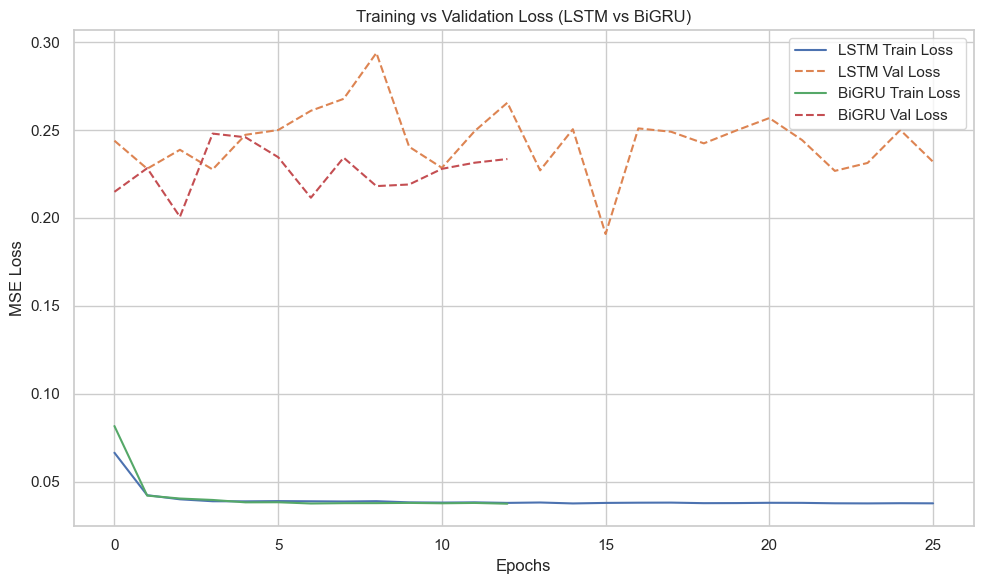

In [5]:
## CELL 5 — Train models (or load saved models if you have them)

nfeat = X_train.shape[2]
callbacks = [EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
             ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5)]

LOAD_SAVED_MODELS = False   
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

if LOAD_SAVED_MODELS:
    gru = load_model(os.path.join(MODEL_DIR,"gru.h5"))
    lstm = load_model(os.path.join(MODEL_DIR,"lstm.h5"))
    bigru = load_model(os.path.join(MODEL_DIR,"bigru.h5"))
    try:
        bigru_att = load_model(os.path.join(MODEL_DIR,"bigru_att.h5"))
    except:
        bigru_att = bigru
else:
    gru = build_gru(timesteps, nfeat)
    lstm = build_lstm(timesteps, nfeat)
    bigru = build_bigru(timesteps, nfeat)
    try:
        bigru_att = build_bigru_attention(timesteps, nfeat)
    except Exception as e:
        print("Attention build failed, using plain BiGRU:", e)
        bigru_att = bigru

    models = {"GRU": gru, "LSTM": lstm, "BiGRU": bigru, "BiGRU_Att": bigru_att}
    histories = {}
    for name, model in models.items():
        print("Training", name)
        hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                         epochs=50, batch_size=32, callbacks=callbacks, verbose=2)
        histories[name] = hist.history
        # save model
        model.save(os.path.join(MODEL_DIR, f"{name.lower()}.h5"))



        # Collect training histories
history_dict = {}
for name, model in models.items():
    if hasattr(model, "history"):  # check if history exists
        history_dict[name] = model.history.history

# Plot only BiGRU vs LSTM to keep it elegant
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for name in ["LSTM", "BiGRU"]:
    if name in history_dict:
        plt.plot(history_dict[name]["loss"], label=f"{name} Train Loss")
        plt.plot(history_dict[name]["val_loss"], linestyle="--", label=f"{name} Val Loss")

plt.title("Training vs Validation Loss (LSTM vs BiGRU)")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
## CELL 6 — Predictions (scaled) and inverse-scale to original price units

# Get predictions on test set
models = {"GRU": gru, "LSTM": lstm, "BiGRU": bigru, "BiGRU_Att": bigru_att}
preds_scaled = {name: model.predict(X_test).ravel() for name, model in models.items()}

# Ensemble NNLS & stacking on scaled values (validation used)
P_val = np.vstack([models[name].predict(X_val).ravel() for name in models]).T
w, _ = nnls(P_val, y_val)
w = w / w.sum()
P_test = np.vstack([preds_scaled[name] for name in models]).T
pred_ens_scaled = P_test.dot(w)
meta = LinearRegression().fit(P_val, y_val)
pred_stack_scaled = meta.predict(P_test)

preds_scaled["Ensemble"] = pred_ens_scaled
preds_scaled["Stacking"] = pred_stack_scaled

# inverse scaling function (min-max using train min/max computed earlier)
def inv_minmax(scaled_arr, orig_min=price_min_train, orig_max=price_max_train):
    return np.array(scaled_arr) * (orig_max - orig_min) + orig_min

# invert y_test and predictions
y_test_price = inv_minmax(y_test)
preds_price = {k: inv_minmax(v) for k, v in preds_scaled.items()}

# Align ARIMA preds to test_dates
arima_map = arima_df.set_index(pd.to_datetime(arima_df['Date']))['ARIMA_Pred'].to_dict()
arima_preds = np.array([arima_map.get(pd.to_datetime(dt), np.nan) for dt in dates_test])

# Save test predictions CSV (real units)
pred_df = pd.DataFrame({"Date": dates_test, "Actual": y_test_price})
for k, v in preds_price.items():
    pred_df[k] = v
pred_df["ARIMA"] = arima_preds
pred_df.to_csv("../outputs/predictions_test_real_units.csv", index=False)
pred_df.head()


11/11 [==============================] - 0s 9ms/step


,Date,Actual,GRU,LSTM,BiGRU,BiGRU_Att,Ensemble,Stacking,ARIMA
0,2023-08-16,225.5459,54.6793,59.5947,54.8137,63.6151,63.6151,228.0740,328.4568
1,2023-08-17,219.1640,54.6793,59.5947,54.8137,63.6151,63.6151,228.0740,329.0701
2,2023-08-18,215.4329,54.6793,59.5947,54.8137,63.6151,63.6151,228.0740,329.6846
3,2023-08-21,231.2275,54.6793,59.5947,54.8137,63.6151,63.6151,228.0740,330.3002
4,2023-08-22,233.1381,54.6793,59.5947,54.8137,63.6151,63.6151,228.0740,330.9170


In [7]:
## CELL 7 — Compute real-unit metrics and save table (RMSE, MAE, MAPE, R²)

def metrics_real(true, pred):
    # handle nan in ARIMA alignment by dropping pairs with nan
    mask = ~np.isnan(true) & ~np.isnan(pred)
    if mask.sum() == 0:
        return {"RMSE":np.nan, "MAE":np.nan, "MAPE":np.nan, "R2":np.nan}
    tt = true[mask]; pp = pred[mask]
    rmse = sqrt(mean_squared_error(tt, pp))
    mae = mean_absolute_error(tt, pp)
    mape = np.mean(np.abs((tt - pp)/tt)) * 100
    r2 = r2_score(tt, pp)
    return {"RMSE":rmse, "MAE":mae, "MAPE":mape, "R2":r2}

results = {}
# include ARIMA first
results["ARIMA"] = metrics_real(y_test_price, arima_preds)
for name, arr in preds_price.items():
    results[name] = metrics_real(y_test_price, arr)

results_df = pd.DataFrame(results).T[["RMSE","MAE","MAPE","R2"]]
results_df.to_csv("../outputs/results_table_real_units.csv")
results_df



,RMSE,MAE,MAPE,R2
ARIMA,244.0455,229.9651,108.6846,-28.8052
GRU,175.5929,169.8076,74.7509,-14.4300
LSTM,170.8440,164.8922,72.4811,-13.6067
BiGRU,175.4629,169.6731,74.6888,-14.4071
BiGRU_Att,166.9669,160.8717,70.6246,-12.9512
Ensemble,166.9669,160.8717,70.6246,-12.9512
Stacking,44.8351,34.6076,15.9334,-0.0060


In [9]:
## CELL 8 — Diebold–Mariano test (Newey-West HAC variance)


# CELL 8 — Diebold-Mariano with Newey-West HAC
import numpy as np
from scipy.stats import t as student_t, norm

def newey_west_variance(d, lag=None):
    T = len(d)
    dbar = np.mean(d)
    if lag is None:
        lag = int(np.floor(1.2 * T ** (1/3)))
    gamma0 = np.sum((d - dbar)*(d - dbar)) / T
    s = gamma0
    for l in range(1, lag+1):
        gamma_l = np.sum((d[:-l] - dbar)*(d[l:] - dbar)) / T
        weight = 1 - l/(lag+1)
        s += 2 * weight * gamma_l
    return s

def diebold_mariano(y, y1, y2, h=1):
    # y, y1, y2 are arrays in same units (real prices)
    # loss = squared error
    mask = ~np.isnan(y) & ~np.isnan(y1) & ~np.isnan(y2)
    d = (y[mask] - y1[mask])**2 - (y[mask] - y2[mask])**2
    dbar = np.mean(d)
    T = len(d)
    s = newey_west_variance(d, lag= int(np.floor(1.2 * T**(1/3))))
    DM = dbar / np.sqrt(s / T) if s>0 else np.nan
    pval = 2 * norm.sf(abs(DM))
    return DM, pval

# choose baseline for comparison (commonly best model)
baseline = "Stacking" if "Stacking" in preds_price else "BiGRU"
dm_list = []
for model in list(results_df.index):
    if model == baseline: continue
    if model == "ARIMA":
        y1 = preds_price.get(baseline)
        y2 = arima_preds
    else:
        y1 = preds_price.get(baseline)
        y2 = preds_price.get(model)
    DM, pval = diebold_mariano(y_test_price, y1, y2)
    dm_list.append({"Comparison": f"{baseline}_vs_{model}", "DM": DM, "pval": pval})

dm_df = pd.DataFrame(dm_list)
dm_df.to_csv("../outputs/dm_results.csv", index=False)
dm_df


,Comparison,DM,pval
0,Stacking_vs_ARIMA,-10.3429,0.0000
1,Stacking_vs_GRU,-11.9385,0.0000
2,Stacking_vs_LSTM,-11.5853,0.0000
3,Stacking_vs_BiGRU,-11.9288,0.0000
4,Stacking_vs_BiGRU_Att,-11.2963,0.0000
5,Stacking_vs_Ensemble,-11.2963,0.0000


In [10]:
import pandas as pd

# Load processed dataset (training + validation + test merged if needed)
train = pd.read_csv("C:/Users/User/Desktop/Fii project/New Project 1/New Project 1/processed/train_scaled.csv")
val   = pd.read_csv("C:/Users/User/Desktop/Fii project/New Project 1/New Project 1/processed/val_scaled.csv")
test  = pd.read_csv("C:/Users/User/Desktop/Fii project/New Project 1/New Project 1/processed/test_scaled.csv")

df = pd.concat([train, val, test])

# Compute descriptive stats for selected variables
desc = df[["Price", "SMA_14", "RSI_14", "Volume"]].describe().T
desc = desc[["mean", "std", "min", "max"]]

print(desc)
desc.to_csv("C:/Users/User/Desktop/Fii project/New Project 1/New Project 1/outputs/tesla_descriptives.csv")


                 mean    std            min            max
Price          0.1943 0.2582         0.0000         1.0000
SMA_14         0.2117 0.2815         0.0000         1.0000
RSI_14         0.4548 0.1719        -0.0272         1.0000
Volume 281494500.0000 0.0000 281494500.0000 281494500.0000


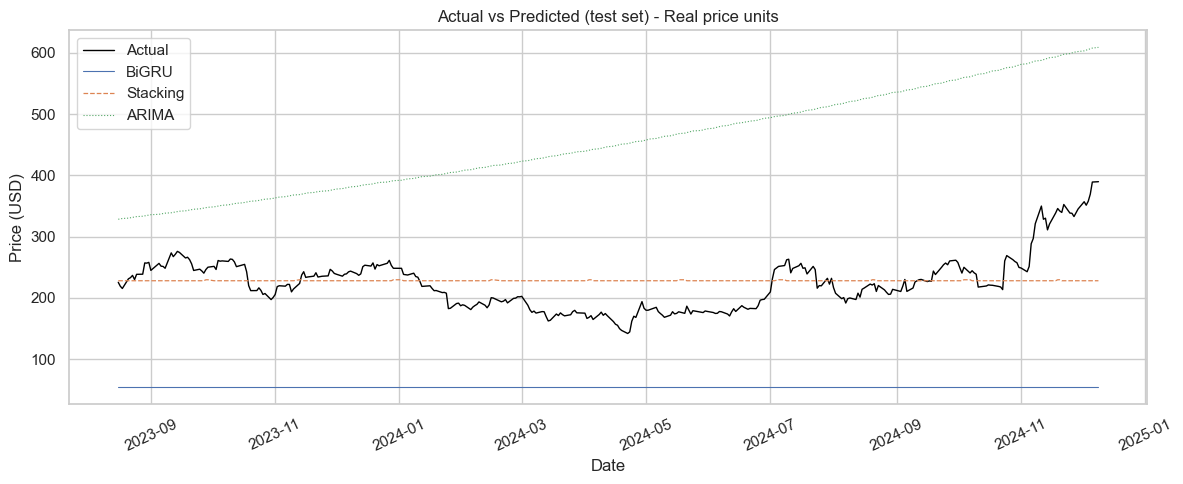

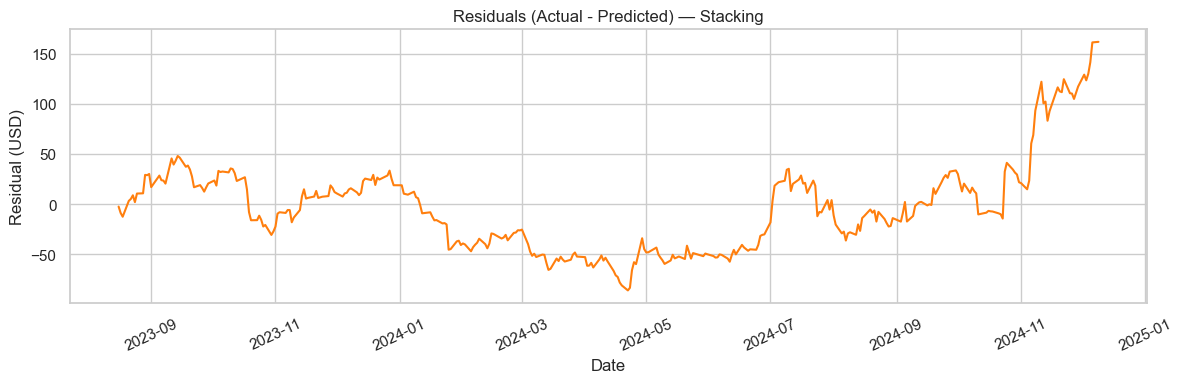

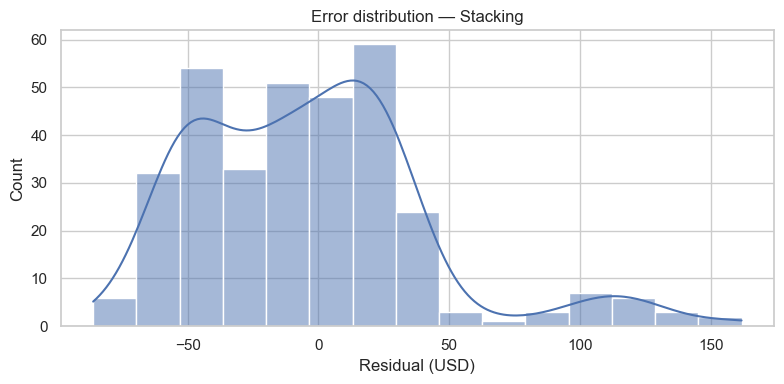

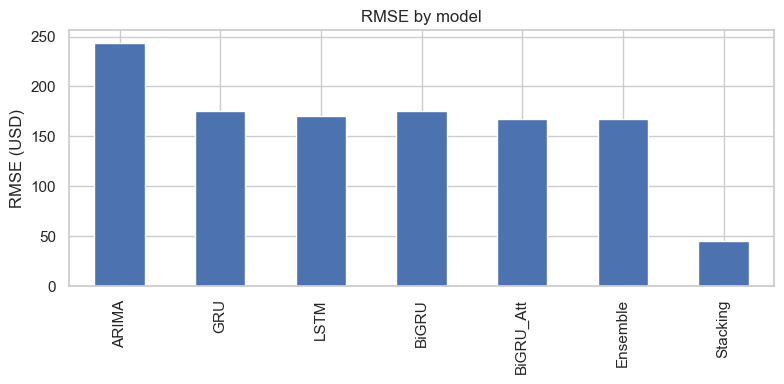

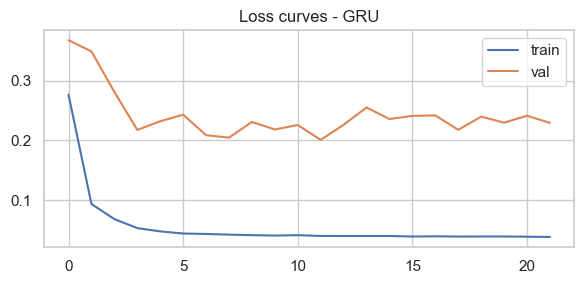

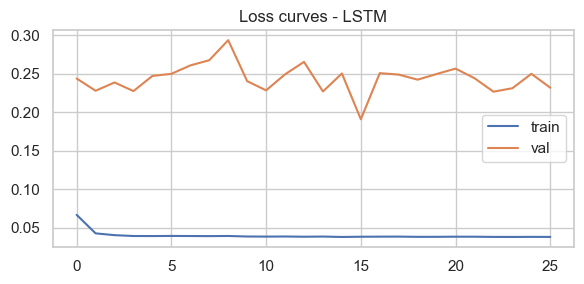

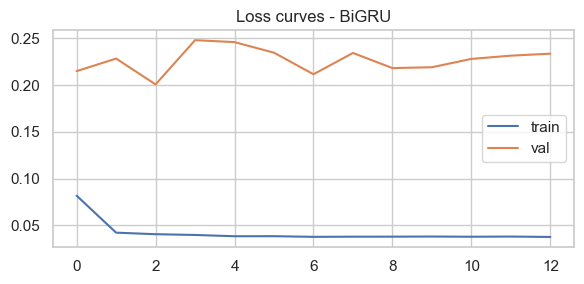

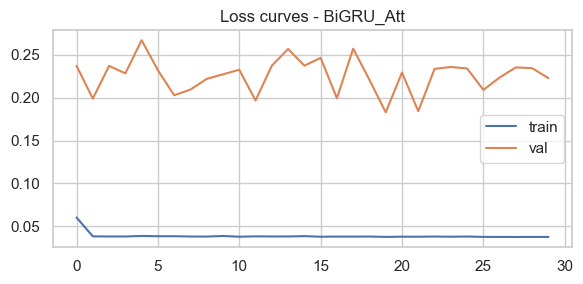

In [11]:
## CELL 9 — Plots for Chapter 4 (Actual vs Predicted, residuals, error distribution, RMSE bar, training curves)


figdir = "../outputs/figures"

# Fig 1: Actual vs Predicted (ARIMA, BiGRU, Stacking)
plt.figure(figsize=(12,5))
plt.plot(dates_test, y_test_price, label="Actual", color="black", lw=1)
if "BiGRU" in preds_price:
    plt.plot(dates_test, preds_price["BiGRU"], label="BiGRU", lw=0.8)
if "Stacking" in preds_price:
    plt.plot(dates_test, preds_price["Stacking"], label="Stacking", lw=0.9, ls="--")
plt.plot(dates_test, arima_preds, label="ARIMA", ls=":", lw=0.8)
plt.legend(); plt.title("Actual vs Predicted (test set) - Real price units")
plt.xlabel("Date"); plt.ylabel("Price (USD)")
plt.xticks(rotation=25); plt.tight_layout()
plt.savefig(os.path.join(figdir,"actual_vs_models.png"), dpi=300)
plt.show()

# Fig 2: Residuals (best)
best = "Stacking" if "Stacking" in preds_price else "BiGRU"
resid = y_test_price - preds_price[best]
plt.figure(figsize=(12,4))
plt.plot(dates_test, resid, color="tab:orange"); plt.title(f"Residuals (Actual - Predicted) — {best}")
plt.xlabel("Date"); plt.ylabel("Residual (USD)"); plt.xticks(rotation=25); plt.tight_layout()
plt.savefig(os.path.join(figdir,f"residuals_{best}.png"), dpi=300)
plt.show()

# Fig 3: Error distribution
plt.figure(figsize=(8,4))
sns.histplot(resid, kde=True)
plt.title(f"Error distribution — {best}"); plt.xlabel("Residual (USD)"); plt.tight_layout()
plt.savefig(os.path.join(figdir,f"error_dist_{best}.png"), dpi=300)
plt.show()

# Fig 4: RMSE comparison bar chart
plt.figure(figsize=(8,4))
results_df["RMSE"].plot(kind="bar")
plt.ylabel("RMSE (USD)"); plt.title("RMSE by model"); plt.tight_layout()
plt.savefig(os.path.join(figdir,"rmse_comparison.png"), dpi=300)
plt.show()

# Fig 5: Training/validation loss (if you trained here and saved histories)
if 'histories' in globals():
    for name, h in histories.items():
        plt.figure(figsize=(6,3))
        plt.plot(h['loss'], label='train'); plt.plot(h['val_loss'], label='val')
        plt.title(f"Loss curves - {name}"); plt.legend(); plt.tight_layout()
        plt.savefig(os.path.join(figdir,f"loss_{name}.png"), dpi=300)
        plt.show()


Residual summary - BiGRU: {'n': 332, 'mean': 169.6731315256714, 'std': 44.701745569268866, 'median': 165.64065501604168}
Residual summary - Ensemble: {'n': 332, 'mean': 160.8717288884718, 'std': 44.70174511619681, 'median': 156.83925458125162}


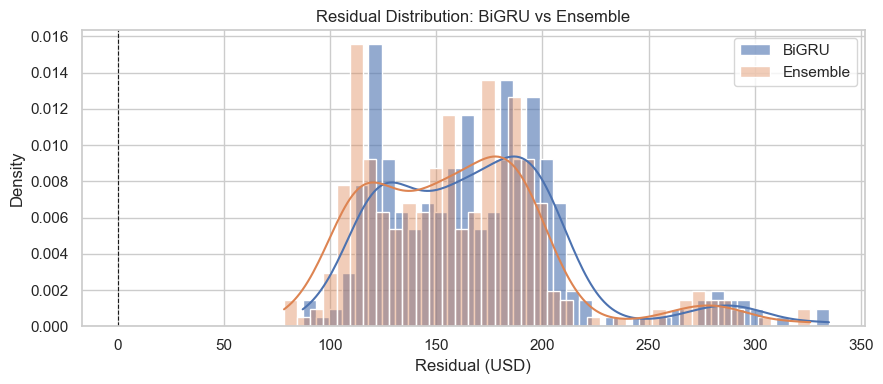

Saved residual distribution to: ../outputs/figures\residual_dist_BiGRU_vs_Ensemble.png
Saved residuals CSV to: ../outputs/residuals_comparison.csv


In [12]:
# CELL B — Residual distribution (BiGRU vs Ensemble)
import numpy as np, seaborn as sns, pandas as pd
import matplotlib.pyplot as plt, os
figdir = "../outputs/figures"
os.makedirs(figdir, exist_ok=True)

# Check required variables
required = all(v in globals() for v in ["y_test_price","preds_price"])
if not required:
    raise RuntimeError("Missing required variables: make sure y_test_price and preds_price exist in the notebook scope.")

# Select models for comparison
model_a = "BiGRU"
model_b = "Ensemble" if "Ensemble" in preds_price else ("Stacking" if "Stacking" in preds_price else None)
if model_a not in preds_price:
    model_a = list(preds_price.keys())[0]   # fallback to first model
if model_b is None:
    print("No Ensemble/Stacking found in preds_price; will compare only BiGRU residual distribution.")
    
# compute residuals (drop nan pairs)
def safe_resid(y_true, y_pred):
    mask = (~np.isnan(y_true)) & (~np.isnan(y_pred))
    return y_true[mask] - y_pred[mask]

res_a = safe_resid(np.array(y_test_price), np.array(preds_price[model_a]))
res_b = safe_resid(np.array(y_test_price), np.array(preds_price[model_b])) if (model_b is not None) else None

# summary stats
def summary_stats(arr):
    return {"n": len(arr), "mean": np.mean(arr), "std": np.std(arr), "median": np.median(arr)}
print(f"Residual summary - {model_a}:", summary_stats(res_a))
if res_b is not None:
    print(f"Residual summary - {model_b}:", summary_stats(res_b))

# plot
plt.figure(figsize=(9,4))
sns.histplot(res_a, stat="density", kde=True, label=f"{model_a}", alpha=0.6, bins=40)
if res_b is not None:
    sns.histplot(res_b, stat="density", kde=True, label=f"{model_b}", alpha=0.4, bins=40)
plt.axvline(0, color='k', linestyle='--', linewidth=0.8)
plt.title(f"Residual Distribution: {model_a} " + (f"vs {model_b}" if res_b is not None else ""))
plt.xlabel("Residual (USD)"); plt.ylabel("Density")
plt.legend(); plt.tight_layout()
fpath = os.path.join(figdir, f"residual_dist_{model_a}" + (f"_vs_{model_b}" if res_b is not None else "") + ".png")
plt.savefig(fpath, dpi=300); plt.show()
print("Saved residual distribution to:", fpath)

# save residuals CSV for records
res_df = pd.DataFrame({"Date": pd.to_datetime(dates_test), f"{model_a}_res": res_a})
if res_b is not None:
    # align lengths to common dates
    common_dates = pd.to_datetime(dates_test)
    res_df[f"{model_b}_res"] = res_b
res_df.to_csv("../outputs/residuals_comparison.csv", index=False)
print("Saved residuals CSV to: ../outputs/residuals_comparison.csv")


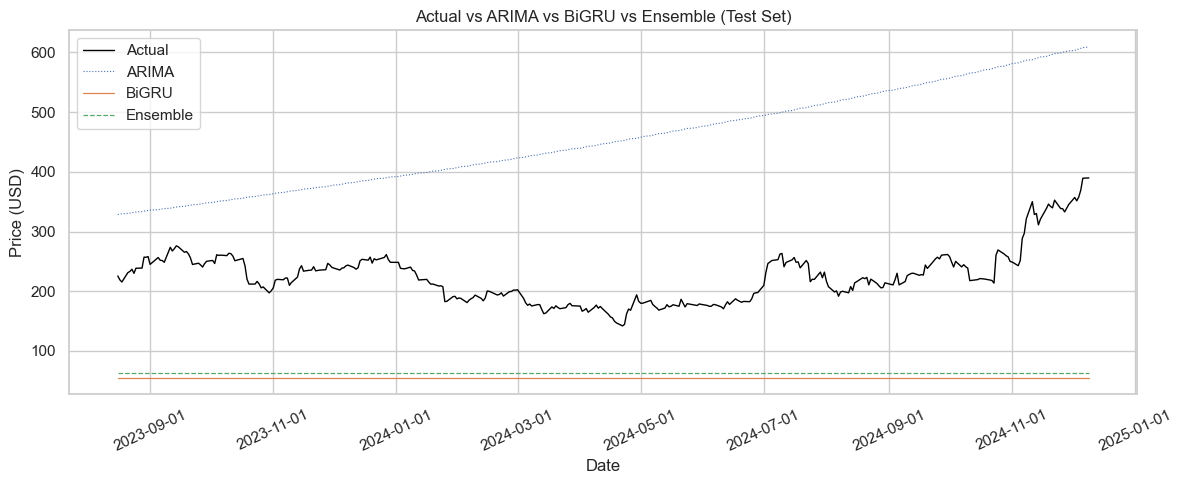

Saved overlay plot to: ../outputs/figures\overlay_actual_arima_bigru_ensemble.png


In [13]:
# CELL C — Overlay plot (Actual vs ARIMA vs BiGRU vs Ensemble)
import matplotlib.dates as mdates, os
figdir = "../outputs/figures"
os.makedirs(figdir, exist_ok=True)

# Ensure all series align
dates = pd.to_datetime(dates_test)
actual = np.array(y_test_price)
# ARIMA: arima_preds array expected aligned to dates_test already (if not, align first)
try:
    arima = np.array(arima_preds)
except NameError:
    # try reading arima CSV
    import pandas as pd
    arima_df = pd.read_csv("processed/arima_test_preds.csv", parse_dates=["Date"])
    map_arima = arima_df.set_index("Date")["ARIMA_Pred"].to_dict()
    arima = np.array([map_arima.get(pd.to_datetime(d), np.nan) for d in dates])

# Choose DL models to plot
plot_models = []
if "BiGRU" in preds_price: plot_models.append("BiGRU")
elif "BiGRU_Att" in preds_price: plot_models.append("BiGRU_Att")
else:
    plot_models.append(list(preds_price.keys())[0])  # fallback

if "Ensemble" in preds_price:
    plot_models.append("Ensemble")
elif "Stacking" in preds_price:
    plot_models.append("Stacking")

# Plot
plt.figure(figsize=(12,5))
plt.plot(dates, actual, label="Actual", color="black", linewidth=1)
plt.plot(dates, arima, label="ARIMA", linestyle=":", linewidth=0.8)
for m in plot_models:
    plt.plot(dates, preds_price[m], label=m, linewidth=0.9, linestyle="--" if m!="BiGRU" else "-")
plt.title("Actual vs ARIMA vs BiGRU vs Ensemble (Test Set)")
plt.xlabel("Date"); plt.ylabel("Price (USD)")
plt.legend(loc="upper left")
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=25); plt.tight_layout()
fpath = os.path.join(figdir, "overlay_actual_arima_bigru_ensemble.png")
plt.savefig(fpath, dpi=300); plt.show()
print("Saved overlay plot to:", fpath)


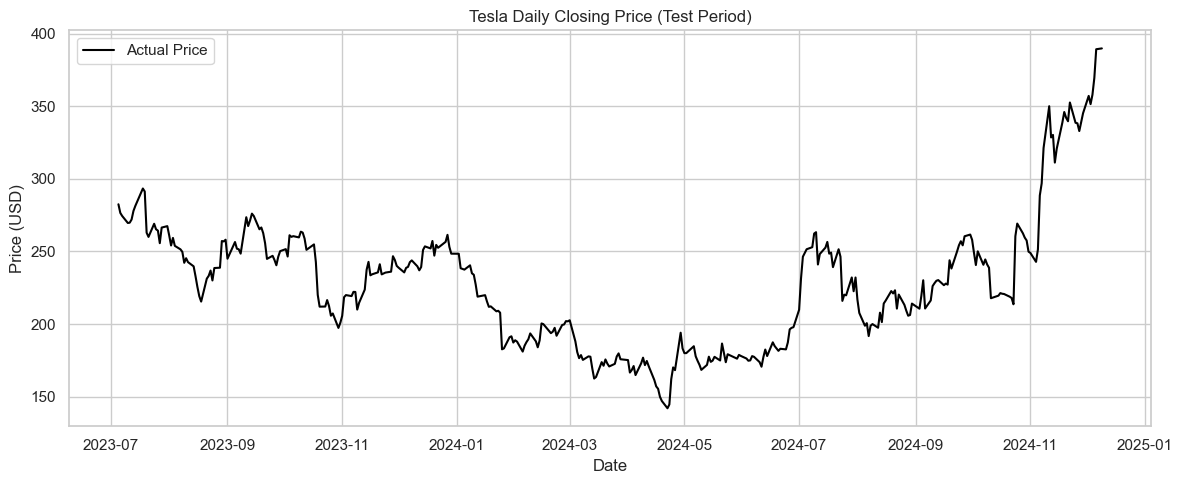

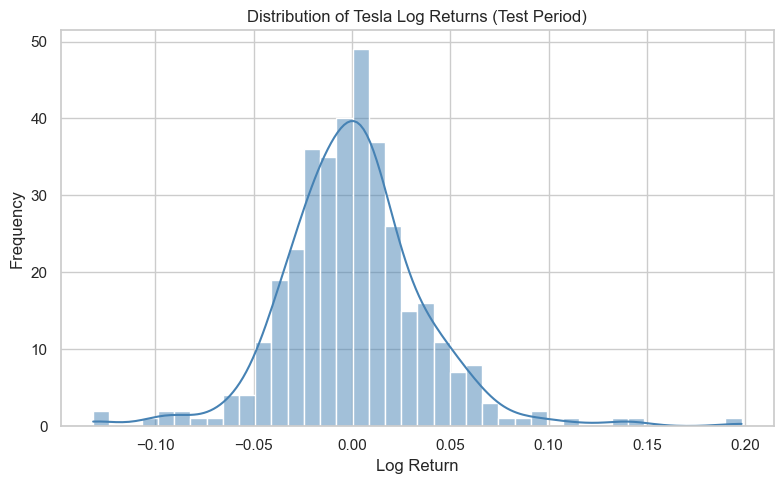

Figures saved under: C:/Users/User/Desktop/Fii project/New Project 1/New Project 1/outputs/figures


In [14]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np   
import os

# Make sure paths are correct
proc_dir = "C:/Users/User/Desktop/Fii project/New Project 1/New Project 1/processed"   
fig_dir = "C:/Users/User/Desktop/Fii project/New Project 1/New Project 1/outputs/figures"
os.makedirs(fig_dir, exist_ok=True)

# Load ARIMA test preds (contains Date, Actual, ARIMA_Pred)
arima_df = pd.read_csv(os.path.join(proc_dir, "arima_test_preds.csv"))
arima_df["Date"] = pd.to_datetime(arima_df["Date"])

# --- Figure 4.1: Tesla daily closing price (test period) ---
plt.figure(figsize=(12,5))
plt.plot(arima_df["Date"], arima_df["Actual"], color="black", label="Actual Price")
plt.title("Tesla Daily Closing Price (Test Period)")
plt.xlabel("Date"); plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "tesla_actual_test_timeseries.png"), dpi=300)
plt.show()   # <-- display inside Jupyter

# --- Figure 4.2: Distribution of log returns (test period) ---
arima_df["LogReturn"] = np.log(arima_df["Actual"]).diff()
plt.figure(figsize=(8,5))
sns.histplot(arima_df["LogReturn"].dropna(), bins=40, kde=True, color="steelblue")
plt.title("Distribution of Tesla Log Returns (Test Period)")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "tesla_returns_test_distribution.png"), dpi=300)
plt.show()   # <-- display inside Jupyter

print("Figures saved under:", fig_dir)



Training GRU...
Epoch 1/50
90/90 - 2s - loss: 0.0394 - val_loss: 0.2311 - lr: 2.5000e-04 - 2s/epoch - 20ms/step
Epoch 2/50
90/90 - 1s - loss: 0.0385 - val_loss: 0.2538 - lr: 2.5000e-04 - 1s/epoch - 14ms/step
Epoch 3/50
90/90 - 1s - loss: 0.0385 - val_loss: 0.2278 - lr: 2.5000e-04 - 1s/epoch - 15ms/step
Epoch 4/50
90/90 - 2s - loss: 0.0385 - val_loss: 0.2323 - lr: 2.5000e-04 - 2s/epoch - 17ms/step
Epoch 5/50
90/90 - 1s - loss: 0.0384 - val_loss: 0.2182 - lr: 2.5000e-04 - 1s/epoch - 15ms/step
Epoch 6/50
90/90 - 1s - loss: 0.0384 - val_loss: 0.2062 - lr: 2.5000e-04 - 1s/epoch - 15ms/step
Epoch 7/50
90/90 - 1s - loss: 0.0394 - val_loss: 0.1849 - lr: 2.5000e-04 - 1s/epoch - 16ms/step
Epoch 8/50
90/90 - 2s - loss: 0.0392 - val_loss: 0.2035 - lr: 2.5000e-04 - 2s/epoch - 18ms/step
Epoch 9/50
90/90 - 2s - loss: 0.0392 - val_loss: 0.1958 - lr: 2.5000e-04 - 2s/epoch - 17ms/step
Epoch 10/50
90/90 - 3s - loss: 0.0385 - val_loss: 0.2215 - lr: 2.5000e-04 - 3s/epoch - 32ms/step
Epoch 11/50
90/90 - 2s 

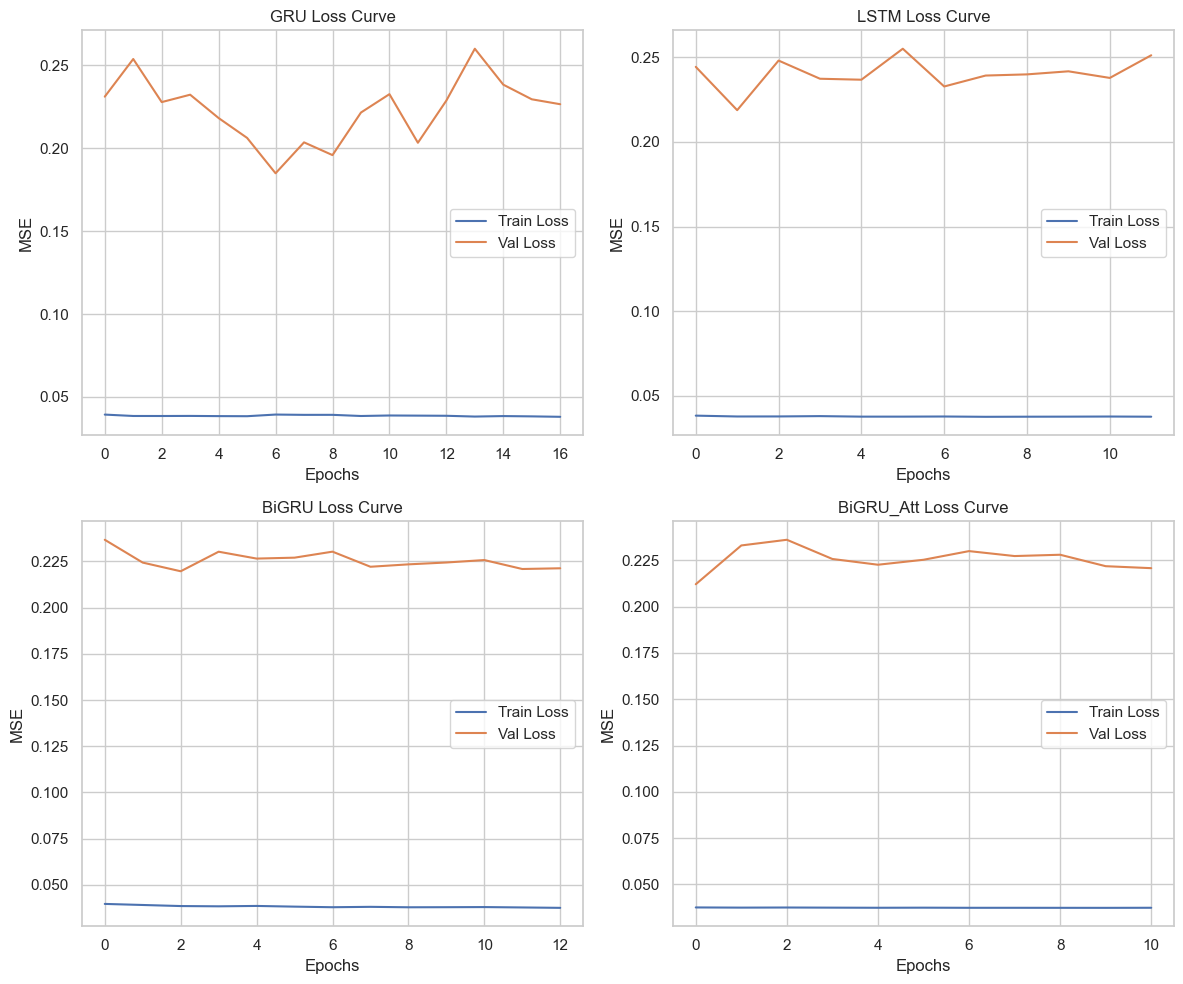

In [15]:
histories = {}

for name, model in models.items():
    print(f"Training {name}...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        callbacks=callbacks,
        verbose=2
    )
    histories[name] = history.history

fig, axes = plt.subplots(2, 2, figsize=(12,10))

for ax, (name, hist) in zip(axes.flatten(), histories.items()):
    ax.plot(hist['loss'], label='Train Loss')
    ax.plot(hist['val_loss'], label='Val Loss')
    ax.set_title(f"{name} Loss Curve")
    ax.set_xlabel("Epochs")
    ax.set_ylabel("MSE")
    ax.legend()

plt.tight_layout()
plt.savefig("C:/Users/User/Desktop/Fii project/New Project 1/New Project 1/outputs/figures/model_loss_curves.png", dpi=300)
plt.show()



In [17]:
## CELL 10 — Save APA-friendly table and quick markdown preview (for copy-paste into Word)

# CELL 10 — export APA-friendly CSV & preview
apa_table = results_df.reset_index().rename(columns={"index":"Model"})
apa_table.to_csv("../outputs/results_table_APA.csv", index=False)
from IPython.display import display, Markdown
display(Markdown(apa_table.to_markdown(index=False)))
print("Saved: ../outputs/results_table_real_units.csv, ../outputs/dm_results.csv, ../outputs/predictions_test_real_units.csv")
print("Figures saved under ../outputs/figures/")



| Model     |    RMSE |     MAE |     MAPE |           R2 |
|:----------|--------:|--------:|---------:|-------------:|
| ARIMA     | 244.045 | 229.965 | 108.685  | -28.8052     |
| GRU       | 163.709 | 157.488 |  69.0619 | -12.412      |
| LSTM      | 173.356 | 167.493 |  73.6823 | -14.0393     |
| BiGRU     | 154.618 | 148.015 |  64.6877 | -10.9638     |
| BiGRU_Att | 113.773 | 104.623 |  44.6509 |  -5.47783    |
| Ensemble  | 163.709 | 157.488 |  69.0619 | -12.412      |
| Stacking  |  44.872 |  34.654 |  15.9793 |  -0.00763152 |

Saved: ../outputs/results_table_real_units.csv, ../outputs/dm_results.csv, ../outputs/predictions_test_real_units.csv
Figures saved under ../outputs/figures/


In [21]:
##compute ARIMA metrics and merge with Python results


# --- Python: compute ARIMA metrics and merge with DL results ---
import os, pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from math import sqrt

# Paths (adjust if needed)
proc_dir = r"C:\Users\User\Desktop\Fii project\New Project 1\New Project 1\processed"
py_outputs = r"C:\Users\User\Desktop\Fii project\New Project 1\New Project 1\outputs"   # notebook outputs folder

arima_file = os.path.join(proc_dir, "arima_test_preds.csv")
# Either read the saved results table from Python (if exists) or predictions file
py_results_file = os.path.join(py_outputs, "results_table_real_units.csv")          # metrics from Python
preds_file      = os.path.join(py_outputs, "predictions_test_real_units.csv")       # predictions vs actual (real units)

# 1) Read ARIMA
arima_df = pd.read_csv(arima_file, parse_dates=["Date"])
arima_df = arima_df.dropna(subset=["ARIMA_Pred","Actual"]).sort_values("Date").reset_index(drop=True)

# compute metrics function (handles possible zeros)
def metrics(true, pred):
    mask = (~np.isnan(true)) & (~np.isnan(pred))
    y_true = np.array(true)[mask]
    y_pred = np.array(pred)[mask]
    if len(y_true)==0:
        return {"RMSE":np.nan,"MAE":np.nan,"MAPE":np.nan,"R2":np.nan}
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred)/np.where(y_true==0, np.nan, y_true)))*100
    r2   = r2_score(y_true, y_pred)
    return {"RMSE":rmse,"MAE":mae,"MAPE":mape,"R2":r2}

arima_metrics = metrics(arima_df["Actual"].values, arima_df["ARIMA_Pred"].values)
arima_row = pd.DataFrame([{"Model":"ARIMA (R)", **arima_metrics}])
arima_row.to_csv(os.path.join(py_outputs,"arima_metrics.csv"), index=False)
print("ARIMA metrics:\n", arima_row)


ARIMA metrics:
        Model     RMSE      MAE     MAPE       R2
0  ARIMA (R) 234.2710 215.4191 101.3939 -26.8590


In [27]:
## 2. Now merge with Python results table (if you already have `results_table_real_units.csv`):

# --- merge ARIMA with Python metrics table ---
py_metrics_path = os.path.join(py_outputs, "results_table_real_units.csv")
if os.path.exists(py_metrics_path):
    py_df = pd.read_csv(py_metrics_path, index_col=0)   # if index is Model
    # ensure consistent column names
    py_df = py_df.reset_index().rename(columns={"index":"Model"})
else:
    # if you don't have precomputed metrics, compute from predictions_test_real_units.csv
    preds_path = os.path.join(py_outputs, "predictions_test_real_units.csv")
    preds_df = pd.read_csv(preds_path, parse_dates=["Date"])
    # preds_df columns: Date, Actual, GRU, LSTM, BiGRU, BiGRU_Att, ARIMA, Ensemble, Stacking
    model_cols = [c for c in preds_df.columns if c not in ["Date","Actual"]]
    rows = []
    for m in model_cols:
        m_metrics = metrics(preds_df["Actual"].values, preds_df[m].values)
        rows.append({"Model":m, **m_metrics})
    py_df = pd.DataFrame(rows)

# append ARIMA row (if not already present)
if "ARIMA (R)" not in list(py_df["Model"]):
    py_df = pd.concat([py_df, arima_row], ignore_index=True)

# reorder rows to put ARIMA first (optional)
order = ["ARIMA (R)"] + [m for m in py_df["Model"] if m!="ARIMA (R)"]
py_df["Model"] = pd.Categorical(py_df["Model"], categories=order, ordered=True)
py_df = py_df.sort_values("Model").reset_index(drop=True)

# Save final comparison table
final_path = os.path.join(py_outputs, "final_model_comparison.csv")
py_df.to_csv(final_path, index=False)
print("Saved final model comparison to:", final_path)
py_df



Saved final model comparison to: C:\Users\User\Desktop\Fii project\New Project 1\New Project 1\outputs\final_model_comparison.csv


,Model,RMSE,MAE,MAPE,R2
0,ARIMA (R),234.2710,215.4191,101.3939,-26.8590
1,ARIMA,244.0455,229.9651,108.6846,-28.8052
2,GRU,163.7088,157.4875,69.0619,-12.4120
3,LSTM,173.3560,167.4934,73.6823,-14.0393
4,BiGRU,154.6178,148.0149,64.6877,-10.9638
5,BiGRU_Att,113.7730,104.6234,44.6509,-5.4778
6,Ensemble,163.7088,157.4875,69.0619,-12.4120
7,Stacking,44.8720,34.6540,15.9793,-0.0076


In [29]:
### 1) Check lengths and date alignment 

##Make sure the ARIMA predictions and your DL test predictions cover the **same test dates**.

# quick alignment check
preds_df = pd.read_csv(os.path.join(py_outputs, "predictions_test_real_units.csv"), parse_dates=["Date"])
arima_dates = set(arima_df["Date"].dt.date)
pred_dates = set(preds_df["Date"].dt.date)
print("ARIMA dates count:", len(arima_dates), "DL pred dates count:", len(pred_dates))
print("dates match?:", arima_dates == pred_dates)
print("dates in ARIMA not in DL:", sorted(list(arima_dates - pred_dates))[:5])

##If mismatch exists: align by intersection:we use the code below

common_dates = sorted(list(arima_dates & pred_dates))
arima_df = arima_df[arima_df["Date"].dt.date.isin(common_dates)]
preds_df = preds_df[preds_df["Date"].dt.date.isin(common_dates)]
# then re-run metrics using these filtered frames




ARIMA dates count: 332 DL pred dates count: 332
dates match?: True
dates in ARIMA not in DL: []


In [16]:
# ---------- BEGIN cell: extract_weights_and_meta_coefs ----------
import os, numpy as np, pandas as pd
from scipy.optimize import nnls
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Where outputs will be saved (relative to current notebook)
OUTDIR = "C:/Users/User/Desktop/Fii project/New Project 1/New Project 1/outputs"
FIGDIR = os.path.join(OUTDIR, "figures")
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)

# ---- Ensure model_names ordering is consistent ----
# If `models` dict exists in your notebook, use its key order. Otherwise define:
try:
    model_names = list(models.keys())
except NameError:
    # If models dictionary is not present, create it by name (adjust if needed)
    raise RuntimeError("`models` dictionary not found. Ensure your notebook defines `models` = {'GRU':..., 'LSTM':..., ...}")

# ---- Build validation matrix P_val and test matrix P_test ----
# If you already computed P_val earlier, this will replace it to ensure consistent ordering.
P_val = np.vstack([models[name].predict(X_val).ravel() for name in model_names]).T  # shape (n_val, M)
P_test = np.vstack([models[name].predict(X_test).ravel() for name in model_names]).T  # shape (n_test, M)

# Sanity checks
assert P_val.shape[1] == len(model_names), "P_val columns mismatch."
assert P_test.shape[1] == len(model_names), "P_test columns mismatch."
print("P_val shape:", P_val.shape, "P_test shape:", P_test.shape)

# ---- NNLS weights ----
w_raw, _rnorm = nnls(P_val, y_val)        # raw non-negative weights (minimize ||P_val w - y_val||_2)
if w_raw.sum() == 0:
    w_norm = w_raw
else:
    w_norm = w_raw / w_raw.sum()         # normalized to sum to 1

# Save weights to CSV
weights_df = pd.DataFrame({
    "model": model_names,
    "nnls_raw": w_raw,
    "nnls_norm": w_norm
})
weights_df.to_csv(os.path.join(OUTDIR, "ensemble_weights.csv"), index=False)
print("\nNNLS weights saved to:", os.path.join(OUTDIR, "ensemble_weights.csv"))
print(weights_df.to_string(index=False))

# ---- Weighted-ensemble test predictions (to be consistent) ----
pred_ens = P_test.dot(w_raw)       # raw-weighted (not normalized). For normalized average, use w_norm.
pred_ens_norm = P_test.dot(w_norm)

# ---- Stacking meta-learner (linear) using sklearn for prediction ----
meta = LinearRegression(fit_intercept=True).fit(P_val, y_val)
pred_stack = meta.predict(P_test)

# ---- Stacking coefficients with inference (statsmodels OLS) ----
# Use statsmodels OLS on P_val with constant to obtain t-stats and p-values
P_val_sm = sm.add_constant(P_val)        # adds intercept column
ols_res = sm.OLS(y_val, P_val_sm).fit(cov_type='HC0')   # robust covariance (HC0)
# ols_res = sm.OLS(y_val, P_val_sm).fit()  # alternative: OLS without robust cov

# Assemble stacking coefficients table
coef_names = ["intercept"] + model_names
coef_values = ols_res.params.tolist()
coef_t = ols_res.tvalues.tolist()
coef_p = ols_res.pvalues.tolist()

stacking_df = pd.DataFrame({
    "term": coef_names,
    "coef": np.round(coef_values, 6),
    "t_stat": np.round(coef_t, 4),
    "p_value": np.round(coef_p, 6)
})
stacking_df.to_csv(os.path.join(OUTDIR, "stacking_coeffs.csv"), index=False)
print("\nStacking coefficients saved to:", os.path.join(OUTDIR, "stacking_coeffs.csv"))
print(stacking_df.to_string(index=False))

# ---- Save combined ensemble summary (weights + stacking coefs side-by-side) ----
combined = weights_df.copy()
# Align stacking coefs (skip intercept for combined weights table)
combined = combined.merge(
    stacking_df[stacking_df["term"] != "intercept"][["term", "coef"]],
    left_on="model", right_on="term", how="left"
).drop(columns=["term"])
combined = combined.rename(columns={"coef": "stacking_beta"})
combined["stacking_beta"] = combined["stacking_beta"].round(6)
combined.to_csv(os.path.join(OUTDIR, "ensemble_weights_and_meta.csv"), index=False)
print("\nCombined table saved to:", os.path.join(OUTDIR, "ensemble_weights_and_meta.csv"))
print(combined.to_string(index=False))

# ---- Save the ensemble/test predictions (for reproducibility & plotting) ----
predictions_df = pd.DataFrame({
    "Date": dates_test,
    "Actual": y_test,
})
# attach base model preds and ensembles
for i, name in enumerate(model_names):
    predictions_df[f"pred_{name}"] = P_test[:, i]
predictions_df["pred_ens_nnls_raw"] = pred_ens
predictions_df["pred_ens_nnls_norm"] = pred_ens_norm
predictions_df["pred_stack"] = pred_stack

predictions_df.to_csv(os.path.join(OUTDIR, "predictions_test_with_ensembles.csv"), index=False)
print("\nPredictions saved to:", os.path.join(OUTDIR, "predictions_test_with_ensembles.csv"))

# ---- Print quick summary of normalized weights and stacking performance ----
print("\nNormalized NNLS weights (for plotting):")
for name, wn in zip(model_names, w_norm):
    print(f"  {name}: {wn:.6f}")

print("\nStacking meta-learner intercept and coefficients (sklearn meta):")
print("  intercept (meta):", meta.intercept_)
for name, coef in zip(model_names, meta.coef_):
    print(f"  {name}: {coef:.6f}")

# Save OLS summary (text) for record
with open(os.path.join(OUTDIR, "stacking_ols_summary.txt"), "w") as f:
    f.write(ols_res.summary().as_text())
print("\nOLS summary saved to:", os.path.join(OUTDIR, "stacking_ols_summary.txt"))
# ---------- END cell ----------


11/11 [==============================] - 0s 10ms/step
P_val shape: (331, 4) P_test shape: (332, 4)

NNLS weights saved to: C:/Users/User/Desktop/Fii project/New Project 1/New Project 1/outputs\ensemble_weights.csv
    model  nnls_raw  nnls_norm
      GRU    0.0000     0.0000
     LSTM    0.0000     0.0000
    BiGRU    0.0000     0.0000
BiGRU_Att    4.6980     1.0000

Stacking coefficients saved to: C:/Users/User/Desktop/Fii project/New Project 1/New Project 1/outputs\stacking_coeffs.csv
     term        coef  t_stat  p_value
intercept   7533.0963  0.1258   0.8999
      GRU -48815.6546 -0.1257   0.8999
     LSTM  -9155.8039 -0.1257   0.8999
    BiGRU  -4168.9206 -0.1257   0.8999
BiGRU_Att  10880.5286  0.1257   0.8999

Combined table saved to: C:/Users/User/Desktop/Fii project/New Project 1/New Project 1/outputs\ensemble_weights_and_meta.csv
    model  nnls_raw  nnls_norm  stacking_beta
      GRU    0.0000     0.0000    -48815.6546
     LSTM    0.0000     0.0000     -9155.8039
    BiGRU 

c:\Users\User\miniconda3\envs\tesla_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 1
  warnings.warn('covariance of constraints does not have full '
